In [1]:
from astropy.table import Table, vstack
import numpy as np
import tqdm
import matplotlib.pyplot as plt
import matplotlib as mpl

from IPython.display import Image


In [2]:
DATA_FOLDER = '/pscratch/sd/n/nravi/GV_classification/'

## compare with kias values

In [3]:
kias = Table.read(DATA_FOLDER + 'NSA_v1_0_1_vflag_Portsmouth.fits')

In [4]:
nsa = Table.read(DATA_FOLDER + 'nsa_v1_0_1_cd.fits')

In [5]:
nsa_dict = {}
for i in range(len(nsa)):

    nsa_dict[nsa['IAUNAME'][i]] = i

In [6]:
nsa['kias_cd'] = np.ones(len(nsa))**np.nan

In [7]:
for i in tqdm.tqdm(range(len(kias))):

    iauname = kias['IAUNAME'][i]
    i_nsa = nsa_dict[iauname]

    nsa['kias_cd'][i_nsa] = kias['cd'][i]

100%|██████████| 641409/641409 [00:04<00:00, 156986.89it/s]


Text(0, 0.5, 'KIAS $\\Delta (g-i)$')

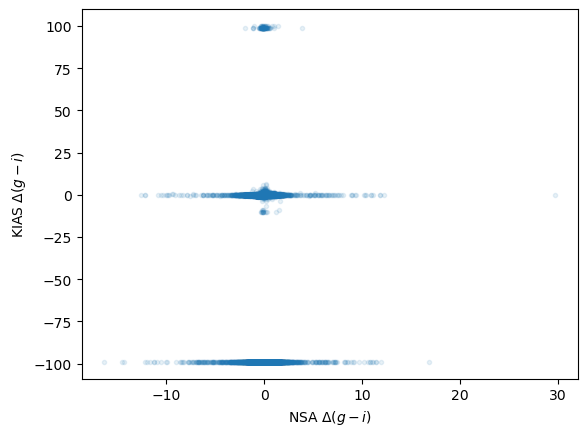

In [8]:
plt.scatter(nsa['NSA_cd'], nsa['kias_cd'], 
          alpha=0.1, marker='.', )
           # bins=100, 
           #range=[[-1, 1], [-5, 5]], 
           # norm=mpl.colors.LogNorm())
plt.xlabel(r'NSA $\Delta (g-i)$')
plt.ylabel(r'KIAS $\Delta (g-i)$')

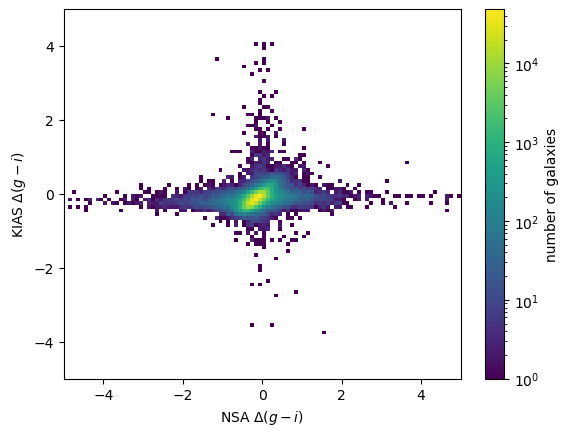

In [9]:
plt.hist2d(nsa['NSA_cd'], nsa['kias_cd'], 
          # alpha=0.1, marker='.', 
           bins=100, 
           range=[[-5, 5], [-5, 5]], 
           norm=mpl.colors.LogNorm())
plt.xlabel(r'NSA $\Delta (g-i)$')
plt.ylabel(r'KIAS $\Delta (g-i)$')
# plt.plot([-1,1],[-1,1], color='r', linewidth=2)
plt.colorbar(label='number of galaxies')

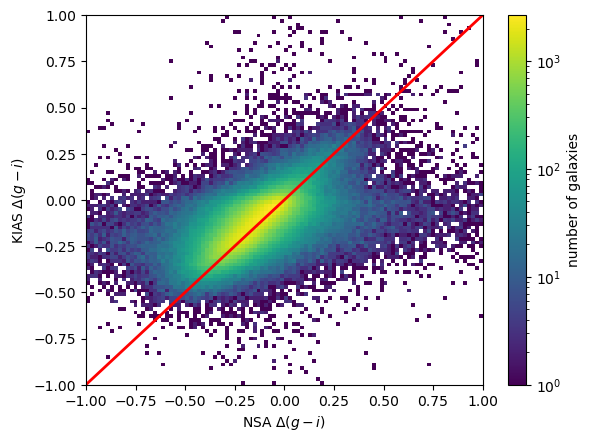

In [10]:
plt.hist2d(nsa['NSA_cd'], nsa['kias_cd'], 
          # alpha=0.1, marker='.', 
           bins=100, 
           range=[[-1, 1], [-1, 1]], 
           norm=mpl.colors.LogNorm())
plt.xlabel(r'NSA $\Delta (g-i)$')
plt.ylabel(r'KIAS $\Delta (g-i)$')
plt.plot([-1,1],[-1,1], color='r', linewidth=2)
plt.colorbar(label='number of galaxies')

### take a closer look at bad NSA fits

In [11]:
nsa_lowcd = nsa[nsa['NSA_cd'] < -3]
nsa_lowcd[:5]

IAUNAME,SUBDIR,RA,DEC,ISDSS,INED,ISIXDF,IALFALFA,IZCAT,ITWODF,MAG,Z,ZSRC,SIZE,RUN,CAMCOL,FIELD,RERUN,XPOS,YPOS,NSAID,ZDIST,SERSIC_NMGY,SERSIC_NMGY_IVAR,SERSIC_OK,SERSIC_RNMGY,SERSIC_ABSMAG,SERSIC_AMIVAR,EXTINCTION,SERSIC_KCORRECT,SERSIC_KCOEFF,SERSIC_MTOL,SERSIC_B300,SERSIC_B1000,SERSIC_METS,SERSIC_MASS,XCEN,YCEN,NPROF,PROFMEAN,PROFMEAN_IVAR,QSTOKES,USTOKES,BASTOKES,PHISTOKES,PETRO_FLUX,PETRO_FLUX_IVAR,FIBER_FLUX,FIBER_FLUX_IVAR,PETRO_BA50,PETRO_PHI50,PETRO_BA90,PETRO_PHI90,SERSIC_FLUX,SERSIC_FLUX_IVAR,SERSIC_N,SERSIC_BA,SERSIC_PHI,ASYMMETRY,CLUMPY,DFLAGS,AID,PID,DVERSION,PROFTHETA,PETRO_THETA,PETRO_TH50,PETRO_TH90,SERSIC_TH50,PLATE,FIBERID,MJD,RACAT,DECCAT,ZSDSSLINE,SURVEY,PROGRAMNAME,PLATEQUALITY,TILE,PLUG_RA,PLUG_DEC,ELPETRO_BA,ELPETRO_PHI,ELPETRO_FLUX_R,ELPETRO_FLUX_IVAR_R,ELPETRO_THETA_R,ELPETRO_TH50_R,ELPETRO_TH90_R,ELPETRO_THETA,ELPETRO_FLUX,ELPETRO_FLUX_IVAR,ELPETRO_TH50,ELPETRO_TH90,ELPETRO_APCORR_R,ELPETRO_APCORR,ELPETRO_APCORR_SELF,ELPETRO_NMGY,ELPETRO_NMGY_IVAR,ELPETRO_OK,ELPETRO_RNMGY,ELPETRO_ABSMAG,ELPETRO_AMIVAR,ELPETRO_KCORRECT,ELPETRO_KCOEFF,ELPETRO_MASS,ELPETRO_MTOL,ELPETRO_B300,ELPETRO_B1000,ELPETRO_METS,IN_DR7_LSS,g_mtot,g_m0,g_a1,g_a2,i_mtot,i_m0,i_a1,i_a2,NSA_cd,g_mtot_err,g_m0_err,g_a1_err,g_a2_err,i_mtot_err,i_m0_err,i_a1_err,i_a2_err,kias_cd
bytes19,bytes27,float64,float64,int32,int32,int32,int32,int32,int32,float32,float32,bytes7,float32,int16,uint8,int16,bytes3,float32,float32,int32,float32,float32[7],float32[7],int16,float32[7],float32[7],float32[7],float32[7],float32[7],float32[5],float32[7],float32,float32,float32,float32,float64,float64,uint8[7],"float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]",float32[7],float32[7],float32[7],float32[7],float32,float32,float32,float32,float32[7],float32[7],float32,float32,float32,float32[7],float32[7],int32[7],int32,int32,bytes8,float32[15],float32,float32,float32,float32,int32,int16,int32,float64,float64,float32,bytes6,bytes27,bytes8,int32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32[7],float32[7],float32[7],float32[7],float32,float32[7],float32[7],float32[7],float32[7],int16,float32[7],float32[7],float32[7],float32[7],float32[5],float32,float32[7],float32,float32,float32,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
J094622.67-000759.3,09h/m00/J094622.67-000759.3,146.5945033810299,-0.1331495973218791,52,72088,-1,-1,-1,-1,17.663818,0.0456523,sdss,0.07,756,3,205,301,762.39856,1366.2919,52,0.045040708,2.4562788 .. 223.59373,1.3131387 .. 0.009723586,1,2.7951224 .. 222.90161,-14.291507 .. -19.108835,6.7207427 .. 412.3795,1.3155904 .. 0.23471148,0.09034476 .. 0.009718234,4.2770625e-06 .. 6.367208e-07,0.000103164864 .. 0.7564231,0.017813168,0.22464368,0.027706578,2.1123058e+09,114.21601867675781,172.5819854736328,10 .. 11,-0.013589629 .. 0.0,4647.482 .. 0.0,-0.10485951 .. -0.09191714,0.022461558 .. -0.1511747,0.806296 .. 0.6993433,83.954796 .. -60.65021,0.4760613 .. -11.061254,2.2048013 .. 0.0017036275,-0.02091508 .. 24.968496,912.88556 .. 0.62378716,0.39801422,158.79947,0.20139216,160.41864,0.7312089 .. 186.88525,14.978843 .. 0.022133123,0.8807852,0.15,161.20255,0.0 .. 0.052722856,0.0 .. 0.0,24 .. 16,0,29,v2_1_13,0.22341923 .. 258.39,13.491169,5.3009696,13.279245,8.639677,266,103,51630,146.59447214304544,-0.13315861572371115,0.0,sdss,legacy,good,122,146.59449,-0.13317431,0.20139216,160.41866,88.32283,0.037014943,16.52506,7.7520294,14.142139,16.52506,-0.07860152 .. 141.89513,5.5062685 .. 0.005654586,-9999.0 .. 6.210911,-9999.0 .. 11.390732,0.9945729,1.0962268 .. 1.0054685,0.9049111 .. 1.0053844,-0.2640384 .. 169.76654,0.48793843 .. 0.0036344046,1,0.7707832 .. 184.16617,-13.349796 .. -18.79659,0.0 .. 88.856415,0.40699738 .. -0.0035067992,7.6083374e-16 .. 6.3167524e-15,1.3116399e+09,0.00017353904 .. 0.57546115,6.8270317e-10,0.16553077,0.02191155,1.0,18.194899311324267,0.3076148

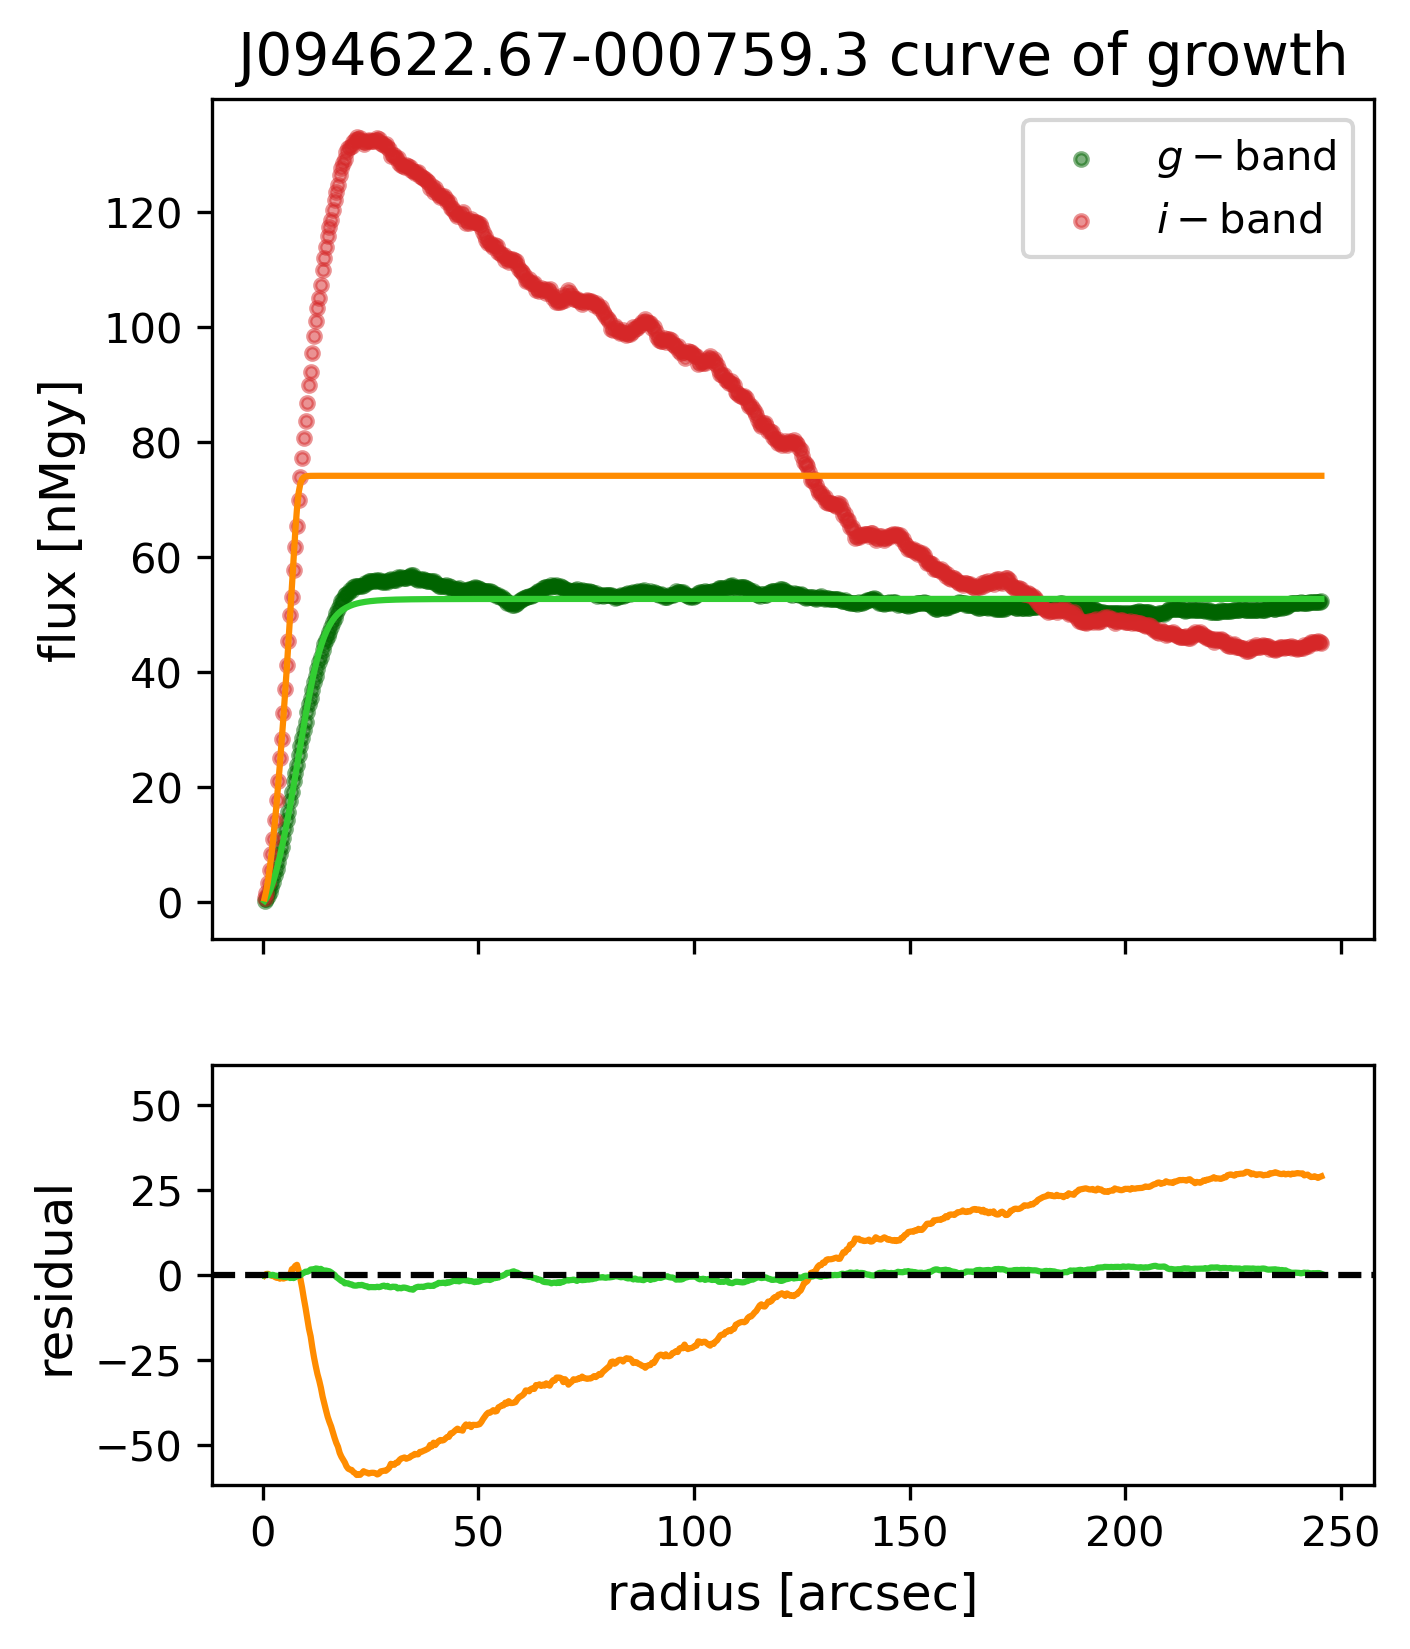

In [12]:
Image(DATA_FOLDER + '/cog_plots/' + str(nsa_lowcd['IAUNAME'][0]) + '.png')

#### color by uncertaintiy on mag_tot

Text(0, 0.5, 'KIAS $\\Delta (g-i)$')

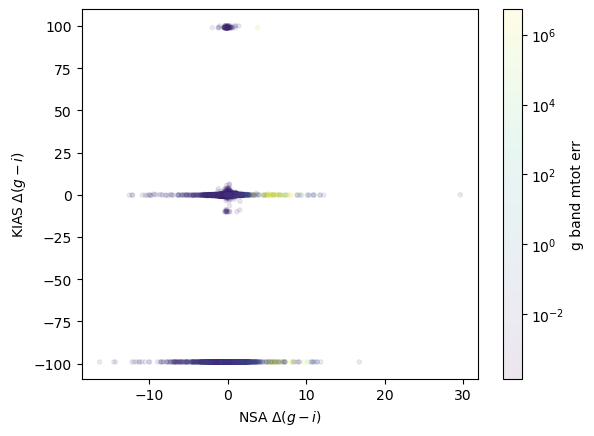

In [17]:
plt.scatter(nsa['NSA_cd'], nsa['kias_cd'], c=nsa['g_mtot_err'],
          alpha=0.1, marker='.', norm=mpl.colors.LogNorm())
plt.colorbar(label='g band mtot err')
plt.xlabel(r'NSA $\Delta (g-i)$')
plt.ylabel(r'KIAS $\Delta (g-i)$')
# plt.plot([-1,1],[-1,1], color='r', linewidth=2)
# plt.colorbar(label='number of galaxies')

(-5.0, 5.0)

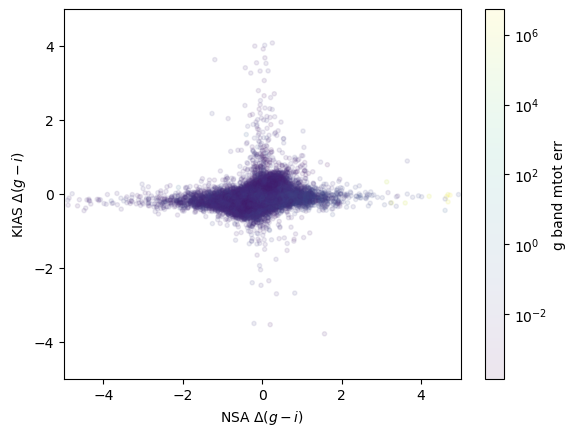

In [18]:
plt.scatter(nsa['NSA_cd'], nsa['kias_cd'], c=nsa['g_mtot_err'],
          alpha=0.1, marker='.', norm=mpl.colors.LogNorm())
plt.colorbar(label='g band mtot err')
plt.xlabel(r'NSA $\Delta (g-i)$')
plt.ylabel(r'KIAS $\Delta (g-i)$')
plt.xlim(-5,5)
plt.ylim(-5,5)

(-5.0, 5.0)

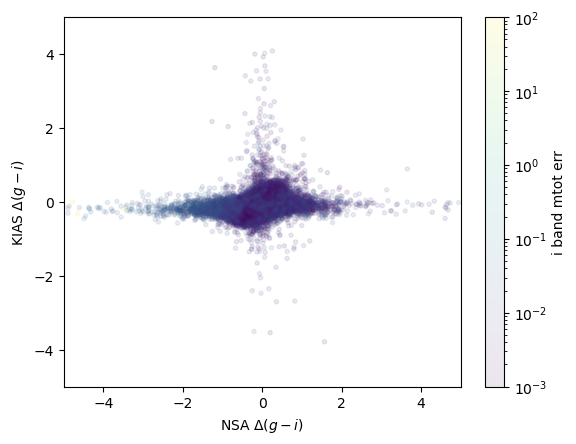

In [49]:
plt.scatter(nsa['NSA_cd'], nsa['kias_cd'], c=nsa['i_mtot_err'],
          alpha=0.1, marker='.', norm=mpl.colors.LogNorm(vmin=10**-3, vmax = 10**2),)
plt.colorbar(label='i band mtot err')
plt.xlabel(r'NSA $\Delta (g-i)$')
plt.ylabel(r'KIAS $\Delta (g-i)$')
plt.xlim(-5,5)
plt.ylim(-5,5)

(array([7.51730e+04, 3.72355e+05, 2.39360e+04, 1.67000e+02, 1.69651e+05,
        6.00000e+00, 1.00000e+00, 3.00000e+00, 1.90000e+01, 9.80000e+01]),
 array([-3.77708738, -2.70783083, -1.63857428, -0.56931772,  0.49993883,
         1.56919538,  2.63845193,  3.70770848,  4.77696503,  5.84622158,
         6.91547814]),
 <BarContainer object of 10 artists>)

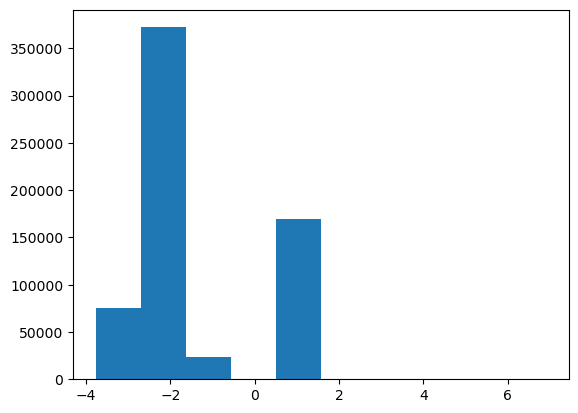

In [26]:
plt.hist(np.log10(nsa['i_mtot_err']))

In [51]:
good_fits = nsa[np.logical_and(np.log10(nsa['g_mtot_err']) < -1, np.log10(nsa['i_mtot_err']) < -1)]

Text(0, 0.5, 'KIAS $\\Delta (g-i)$')

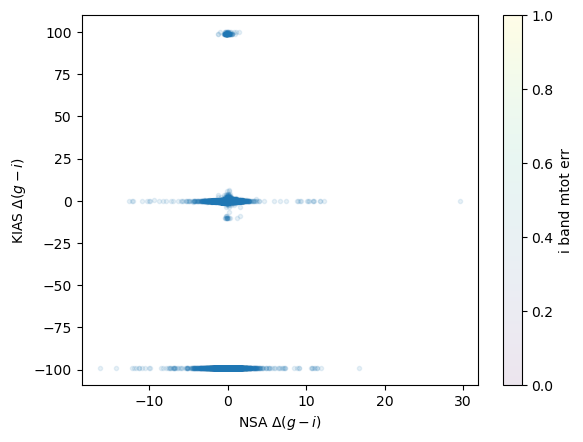

In [52]:
plt.scatter(good_fits['NSA_cd'], good_fits['kias_cd'],
          alpha=0.1, marker='.',)
plt.colorbar(label='i band mtot err')
plt.xlabel(r'NSA $\Delta (g-i)$')
plt.ylabel(r'KIAS $\Delta (g-i)$')
# plt.xlim(-5,5)
# plt.ylim(-5,5)

In [50]:
nsa[0]

IAUNAME,SUBDIR,RA,DEC,ISDSS,INED,ISIXDF,IALFALFA,IZCAT,ITWODF,MAG,Z,ZSRC,SIZE,RUN,CAMCOL,FIELD,RERUN,XPOS,YPOS,NSAID,ZDIST,SERSIC_NMGY,SERSIC_NMGY_IVAR,SERSIC_OK,SERSIC_RNMGY,SERSIC_ABSMAG,SERSIC_AMIVAR,EXTINCTION,SERSIC_KCORRECT,SERSIC_KCOEFF,SERSIC_MTOL,SERSIC_B300,SERSIC_B1000,SERSIC_METS,SERSIC_MASS,XCEN,YCEN,NPROF,PROFMEAN,PROFMEAN_IVAR,QSTOKES,USTOKES,BASTOKES,PHISTOKES,PETRO_FLUX,PETRO_FLUX_IVAR,FIBER_FLUX,FIBER_FLUX_IVAR,PETRO_BA50,PETRO_PHI50,PETRO_BA90,PETRO_PHI90,SERSIC_FLUX,SERSIC_FLUX_IVAR,SERSIC_N,SERSIC_BA,SERSIC_PHI,ASYMMETRY,CLUMPY,DFLAGS,AID,PID,DVERSION,PROFTHETA,PETRO_THETA,PETRO_TH50,PETRO_TH90,SERSIC_TH50,PLATE,FIBERID,MJD,RACAT,DECCAT,ZSDSSLINE,SURVEY,PROGRAMNAME,PLATEQUALITY,TILE,PLUG_RA,PLUG_DEC,ELPETRO_BA,ELPETRO_PHI,ELPETRO_FLUX_R,ELPETRO_FLUX_IVAR_R,ELPETRO_THETA_R,ELPETRO_TH50_R,ELPETRO_TH90_R,ELPETRO_THETA,ELPETRO_FLUX,ELPETRO_FLUX_IVAR,ELPETRO_TH50,ELPETRO_TH90,ELPETRO_APCORR_R,ELPETRO_APCORR,ELPETRO_APCORR_SELF,ELPETRO_NMGY,ELPETRO_NMGY_IVAR,ELPETRO_OK,ELPETRO_RNMGY,ELPETRO_ABSMAG,ELPETRO_AMIVAR,ELPETRO_KCORRECT,ELPETRO_KCOEFF,ELPETRO_MASS,ELPETRO_MTOL,ELPETRO_B300,ELPETRO_B1000,ELPETRO_METS,IN_DR7_LSS,g_mtot,g_m0,g_a1,g_a2,i_mtot,i_m0,i_a1,i_a2,NSA_cd,g_mtot_err,g_m0_err,g_a1_err,g_a2_err,i_mtot_err,i_m0_err,i_a1_err,i_a2_err,kias_cd
bytes19,bytes27,float64,float64,int32,int32,int32,int32,int32,int32,float32,float32,bytes7,float32,int16,uint8,int16,bytes3,float32,float32,int32,float32,float32[7],float32[7],int16,float32[7],float32[7],float32[7],float32[7],float32[7],float32[5],float32[7],float32,float32,float32,float32,float64,float64,uint8[7],"float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]",float32[7],float32[7],float32[7],float32[7],float32,float32,float32,float32,float32[7],float32[7],float32,float32,float32,float32[7],float32[7],int32[7],int32,int32,bytes8,float32[15],float32,float32,float32,float32,int32,int16,int32,float64,float64,float32,bytes6,bytes27,bytes8,int32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32[7],float32[7],float32[7],float32[7],float32,float32[7],float32[7],float32[7],float32[7],int16,float32[7],float32[7],float32[7],float32[7],float32[5],float32,float32[7],float32,float32,float32,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
J094651.40-010228.5,09h/m00/J094651.40-010228.5,146.714215072841,-1.0412800233313741,0,72212,37354,-1,-1,-1,15.178774,0.021222278,sdss,0.07,756,1,206,301,136.2967,1095.152,0,0.020687785,29.696056 .. 3267.6895,0.29814342 .. 0.00012172792,1,31.368013 .. 3501.2527,-15.17281 .. -20.302134,223.03555 .. 1102.6129,0.4536473 .. 0.080934174,-0.005893635 .. 0.019576037,0.00017777947 .. 5.1533486e-11,0.00020792194 .. 0.98780394,2.7473723e-05,0.31195974,0.035135116,8.898397e+09,215.39407348632812,213.4535369873047,10 .. 12,0.3149959 .. 0.0,233.37904 .. 0.0,0.062215745 .. -0.07950058,0.0006146176 .. -0.1274703,0.8828513 .. 0.7387829,0.2829979 .. -60.97547,18.203371 .. 2264.6604,1.9946122 .. 0.015697604,1.0260131 .. 561.97687,47.3397 .. 0.33574256,0.88909996,14.777527,0.80408496,17.367554,19.554192 .. 3146.785,1.0691423 .. 0.017162137,4.7761517,0.6651653,15.97821,-0.0109440535 .. 0.004525926,0.042470127 .. 0.042621203,0 .. 0,0,36,v2_1_13,0.22341923 .. 258.39,7.2478933,3.4641922,10.453795,5.882104,266,1,51630,146.71420341874853,-1.0412749124036818,0.0,sdss,legacy,good,122,146.71421,-1.0413043,0.80408496,17.367554,1144.0713,0.4582725,7.3913364,3.7061903,10.666219,7.3913364,18.787916 .. 2225.009,1.8480047 .. 0.017611798,5.8557696 .. 3.4004514,11.650886 .. 10.1460905,0.9986329,1.0687045 .. 1.001099,1.0695114 .. 1.0010818,28.532349 .. 2310.4973,0.42499655 .. 0.00024172392,1,28.661283 .. 2337.7668,-15.124495 .. -19.915525,293.50247 .. 1094.6666,-0.010805 .. 0.009306902,3.9630737e-05 .. 2.6251464e-06,6.833158e+09,0.00017553588 .. 1.14686,0.004447123,0.09061434,0.025269886,0.0,1

(array([2.4000e+01, 1.9000e+01, 1.8000e+01, 3.2000e+01, 2.6000e+01,
        3.4000e+01, 3.7000e+01, 5.0000e+01, 3.1000e+01, 4.8000e+01,
        5.2000e+01, 4.8000e+01, 5.4000e+01, 5.2000e+01, 5.3000e+01,
        5.8000e+01, 6.7000e+01, 7.4000e+01, 1.0300e+02, 1.1300e+02,
        1.1000e+02, 1.1300e+02, 1.2800e+02, 1.4400e+02, 1.6200e+02,
        1.9100e+02, 1.7900e+02, 2.4400e+02, 2.9300e+02, 2.9100e+02,
        3.9100e+02, 4.4100e+02, 5.8900e+02, 7.4800e+02, 1.0150e+03,
        1.5030e+03, 2.4240e+03, 3.8200e+03, 6.0520e+03, 9.7870e+03,
        1.5448e+04, 2.2819e+04, 3.1510e+04, 3.9491e+04, 4.5798e+04,
        4.8848e+04, 4.9604e+04, 4.8060e+04, 4.2543e+04, 3.0612e+04,
        1.9239e+04, 1.2441e+04, 8.3660e+03, 5.8150e+03, 3.9670e+03,
        2.8330e+03, 2.0940e+03, 1.5870e+03, 1.1740e+03, 8.7100e+02,
        6.8900e+02, 5.4900e+02, 4.8100e+02, 3.9000e+02, 3.4400e+02,
        2.6900e+02, 2.4600e+02, 2.0400e+02, 1.8500e+02, 1.6700e+02,
        1.6800e+02, 1.6500e+02, 1.2900e+02, 1.19

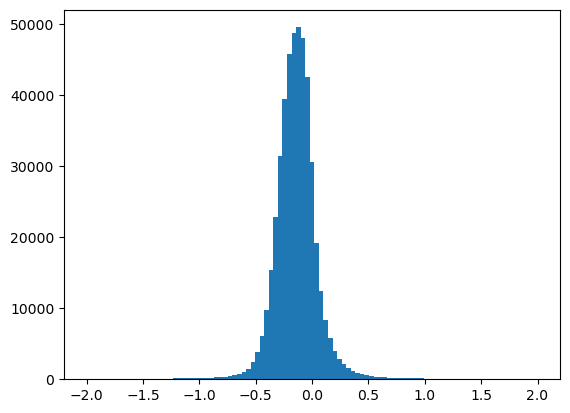

In [58]:
plt.hist(nsa['NSA_cd'], bins=np.linspace(-2,2,100))

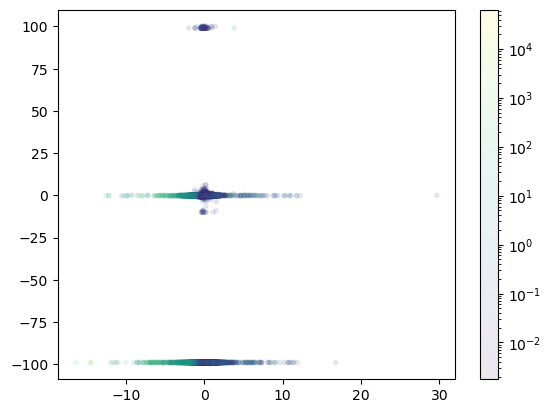

In [62]:
plt.scatter(nsa['NSA_cd'], nsa['kias_cd'], c=nsa['i_a2_err'], alpha=0.1,
           norm=mpl.colors.LogNorm(), marker='.')
plt.colorbar()

(-5.0, 5.0)

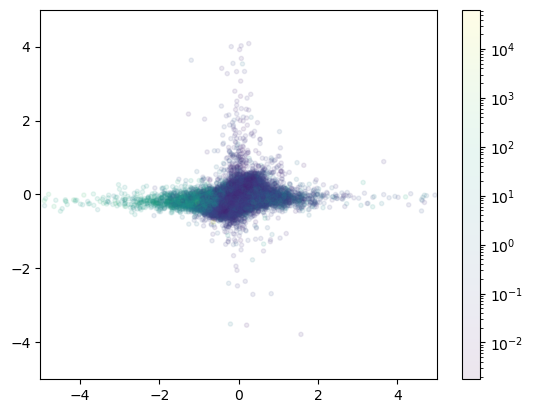

In [63]:
plt.scatter(nsa['NSA_cd'], nsa['kias_cd'], c=nsa['i_a2_err'], alpha=0.1,
           norm=mpl.colors.LogNorm(), marker='.')
plt.colorbar()
plt.xlim(-5,5)
plt.ylim(-5,5)

(array([0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 1.00000e+00, 0.00000e+00, 2.00000e+00, 5.00000e+00,
        6.00000e+00, 9.00000e+00, 1.90000e+01, 3.10000e+01, 5.40000e+01,
        9.40000e+01, 1.32000e+02, 2.12000e+02, 3.78000e+02, 4.89000e+02,
        7.32000e+02, 9.93000e+02, 1.29400e+03, 1.84700e+03, 2.44200e+03,
        3.05000e+03, 3.68600e+03, 4.60900e+03, 5.57500e+03, 6.56800e+03,
        7.87900e+03, 9.02800e+03, 1.02430e+04, 1.19290e+04, 1.34270e+04,
        1.49970e+04, 1.66300e+04, 1.78490e+04, 1.93170e+04, 2.03560e+04,
        2.13830e+04, 2.19180e+04, 2.20710e+04, 2.13160e+04, 2.06570e+04,
        1.93750e+04, 1.82800e+04, 1.62170e+04, 1.42700e+04, 1.22570e+04,
        1.04790e+04, 8.77700e+03, 7.17600e+03, 6.31600e+03, 5.49100e+03,
        4.68600e+03, 4.08100e+03, 3.93300e+03, 3.49200e+03, 3.18200e+03,
        3.10200e+03, 2.85600e+03, 2.70600e+03, 2.55700e+03, 2.29000e+03,
        2.19900e+03, 2.00000e+03, 1.96100e+03, 1.86

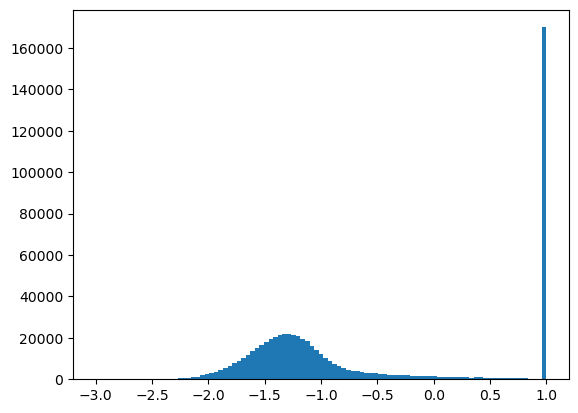

In [70]:
plt.hist(np.log10(np.abs(nsa['i_a2_err'])), bins=np.linspace(-3,1,100))

(-5.0, 5.0)

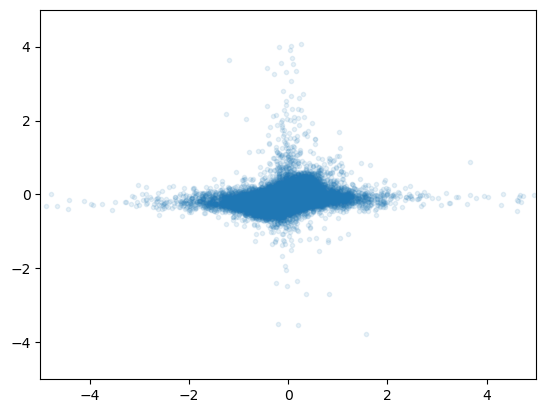

In [76]:
plt.scatter(nsa['NSA_cd'][np.abs(nsa['i_a2']) < 10], nsa['kias_cd'][np.abs(nsa['i_a2']) < 10], marker='.', alpha=0.1)
plt.xlim(-5,5)
plt.ylim(-5,5)

(-5.0, 5.0)

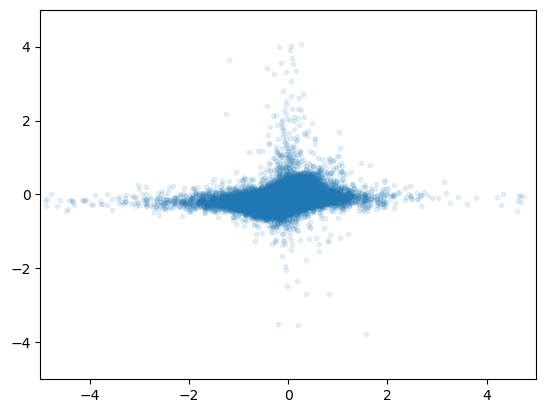

In [77]:
plt.scatter(nsa['NSA_cd'][np.abs(nsa['g_a2']) < 10], nsa['kias_cd'][np.abs(nsa['g_a2']) < 10], marker='.', alpha=0.1)
plt.xlim(-5,5)
plt.ylim(-5,5)